# SPI

Exploration for new format of SPI data (changed by NOAA July 2023)

In [2]:
%load_ext jupyter_black

In [3]:
import datetime
import pandas as pd
import xarray as xr
import numpy as np
import itertools
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

from ochanticipy import (
    create_country_config,
    CodAB,
    GeoBoundingBox,
)

from dotenv import load_dotenv
from pathlib import Path
import os

In [4]:
load_dotenv()

NEW_CMORPH_DIR = Path(os.environ["NEW_CMORPH_DIR"])
AA_DATA_DIR = Path(os.environ["AA_DATA_DIR"])
SPI_PROC_DIR = AA_DATA_DIR / "public/processed/bfa/cmorph_spi/new"

<xarray.DataArray 'spi_1' (date: 1, y: 24, x: 33)>
[792 values with dtype=float64]
Coordinates:
  * date     (date) datetime64[ns] 2024-09-25
  * x        (x) float64 -5.625 -5.375 -5.125 -4.875 ... 1.625 1.875 2.125 2.375
  * y        (y) float64 15.12 14.88 14.62 14.38 ... 10.12 9.875 9.625 9.375
Attributes:
    AREA_OR_POINT:  Area
    long_name:      spi
    grid_mapping:   spatial_ref

<xarray.DataArray 'spi_1' (date: 1, y: 600, x: 825)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * x            (x) float64 -5.745 -5.735 -5.725 -5.715 ... 2.475 2.485 2.495
  * y            (y) float64 15.24 15.23 15.22 15.21 ... 9.285 9.275 9.265 9.255
  * date         (date) datetime64[ns] 2024-09-25
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    long_name:      spi
    grid_mapping:   spatial_ref

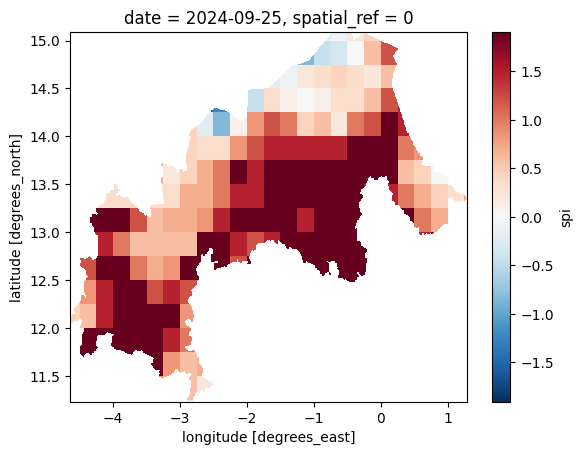

In [5]:
iso3 = "bfa"
adm_sel = ["Boucle du Mouhoun", "Nord", "Centre-Nord", "Sahel"]

country_config = create_country_config(iso3=iso3)
codab = CodAB(country_config=country_config)
gdf_adm1 = codab.load(admin_level=1)
gdf_aoi = gdf_adm1[gdf_adm1["ADM1_FR"].isin(adm_sel)]

date = datetime.date(2024, 9, 25)
filename = f"bfa-spi1-{date}.nc"
ds = xr.open_dataset(SPI_PROC_DIR / filename)
da = ds["spi_1"]
display(da)
da.rio.write_crs("EPSG:4326", inplace=True)
resolution = 0.01
da = da.rio.reproject(
    dst_crs="EPSG:4326",
    resolution=resolution,
    resampling=Resampling.nearest,
)
display(da)
da = da.rio.clip(gdf_aoi["geometry"], all_touched=True)
df = da.to_dataframe()["spi_1"].reset_index().dropna()
da.plot()

spi_1
(0.0, inf]      0.940032
(-0.5, 0.0]     0.051182
(-1.0, -0.5]    0.007965
(-1.5, -1.0]    0.000821
(-inf, -2.0]    0.000000
(-2.0, -1.5]    0.000000
Name: count, dtype: float64


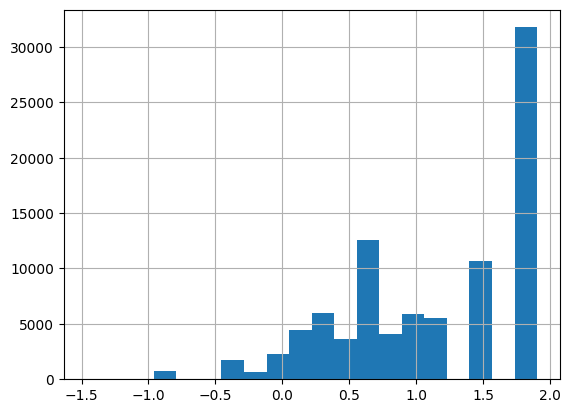

In [6]:
df["spi_1"].hist(bins=20)

bins = [-np.inf, -2, -1.5, -1, -0.5, 0, np.inf]
df_cut = pd.cut(df["spi_1"], bins).value_counts() / len(df)
print(df_cut)

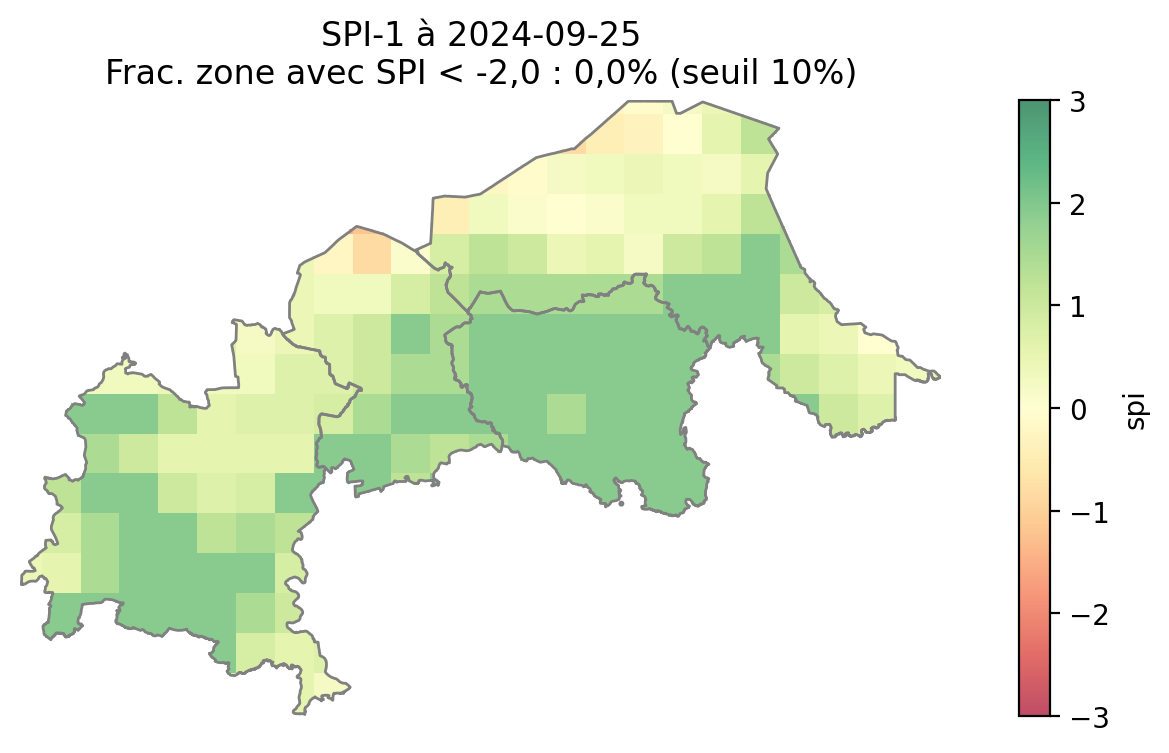

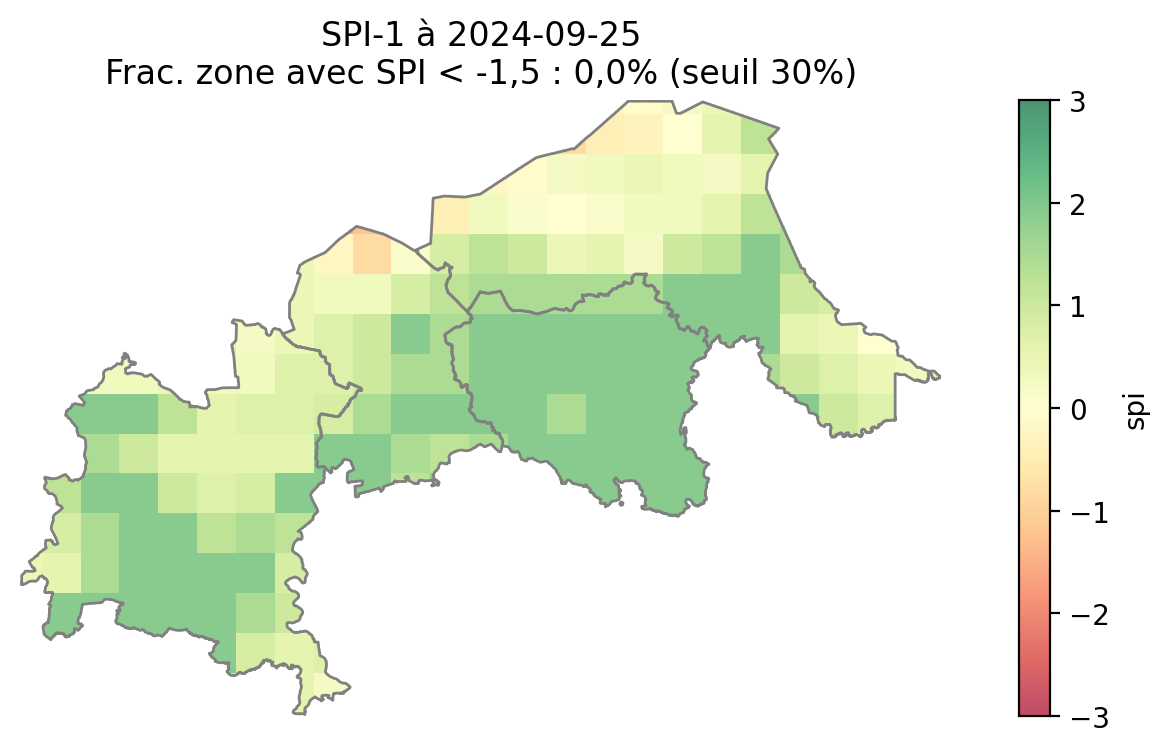

In [7]:
# plot SPI with calc

thresholds = [-2, -1.5]
cutoffs = [10, 30]

for threshold, cutoff in zip(thresholds, cutoffs):
    percent = len(df[df["spi_1"] < threshold]) / len(df) * 100

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
    ax.axis("off")

    gdf_aoi.boundary.plot(linewidth=1, ax=ax, color="grey")
    da.plot(ax=ax, cmap="RdYlGn", vmin=-3, vmax=3, alpha=0.7)
    da.isel(date=0).plot.contour(
        levels=[-100, threshold - 0.0001, 100],
        ax=ax,
        cmap="Reds",
        linewidths=1.5,
    )
    fr_percent = f"{percent:.1f}".replace(".", ",")
    fr_threshold = f"{threshold:.1f}".replace(".", ",")
    ax.set_title(
        f"SPI-1 à {date:%Y-%m-%d}\nFrac. zone avec SPI < {fr_threshold} : "
        f"{fr_percent}% (seuil {cutoff}%)"
    )

In [8]:
da.min()

<xarray.DataArray 'spi_1' ()>
array(-1.4655158)
Coordinates:
    spatial_ref  int64 0

In [11]:
da.quantile(0.3)

<xarray.DataArray 'spi_1' ()>
array(0.69685824)
Coordinates:
    quantile  float64 0.3